*© 2026 Zettnq · oi-volume-signal-research · MIT License*
### 08. S4 — Multi-Timeframe Triggers (5m)
Hypothesis: the impulse is smeared within the gap-hour (Test 0, notebook 05), so a 5m confirmation within the hour may capture it causally.
Design: S4-A (oracle: trigger within a known gap hour) vs S4-B (causal: monitoring after each 1h signal with reset) + controls.
Key decomposition: bias = S4-A − S4-B — a quantitative measure of hindsight selection.
Controls: A (random hour, right-side) — baseline; B (gap hour, wrong-side) — directionality; C (random hour, wrong-side) — baseline intraday mean reversion.

In [1]:
from pathlib import Path

import oivdc_research  # installed via `pip install -e .`

# repo root: .../repo/src/oivdcr_research/__init__.py -> parents[2] = repo
PROJECT_ROOT = Path(oivdc_research.__file__).resolve().parents[2]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from oivdc_research.config import get_config

# Reproducibility parameters — edit here.
ASSET = "btcusdt"
TIMEFRAME = "1h"

CONFIG = get_config(
    project_root=PROJECT_ROOT,
    raw_csv_path=PROJECT_ROOT / "data" / "raw" / f"{ASSET}_{TIMEFRAME}.csv",
    timeframe=TIMEFRAME,
    asset=ASSET,
)

from oivdc_research.forward_returns import load_forward_returns
from oivdc_research.intrabar import (
    build_5m_arrays, build_s4_events, build_s4_causal_events,
    build_control_a, build_control_b, build_control_c,
    extract_s1_events,
)
from oivdc_research.intrabar.data5m import load_5m_data

# 5min horizons
HS5 = (1, 2, 3, 6, 12)

df = load_forward_returns(CONFIG)
df5m = load_5m_data(CONFIG)
a = build_5m_arrays(df5m)
s1 = extract_s1_events(df, CONFIG)

In [2]:
s4a = build_s4_events(a, s1, CONFIG, horizons=HS5)
s4b = build_s4_causal_events(a, df, CONFIG, horizons=HS5)
ctrl_a = build_control_a(a, s1, CONFIG, horizons=HS5)
ctrl_b = build_control_b(a, s1, CONFIG, horizons=HS5)
ctrl_c = build_control_c(a, s1, CONFIG, horizons=HS5)

def summary(events, tag):
    out = []
    for h in HS5:
        x = events[f"pnl_{h}"].dropna()
        if len(x) == 0:
            continue
        out.append([tag, h, len(x), x.mean(), x.std() / np.sqrt(len(x)), (x > 0).mean()])
    return out

rows = (summary(s4a, "S4-A") + summary(s4b, "S4-B") + summary(ctrl_a, "CTRL-A")
        + summary(ctrl_b, "CTRL-B") + summary(ctrl_c, "CTRL-C"))
tab = pd.DataFrame(rows, columns=["src", "h", "n", "mean_pnl", "se", "winrate"])
tab["t"] = tab["mean_pnl"] / tab["se"]
print(tab.pivot(index="h", columns="src", values=["mean_pnl", "winrate", "t"]).round(4))

    mean_pnl                              winrate                          \
src   CTRL-A  CTRL-B  CTRL-C    S4-A S4-B  CTRL-A  CTRL-B  CTRL-C    S4-A   
h                                                                           
1    -0.0000  0.0001  0.0000  0.0001 -0.0  0.4980  0.5516  0.5082  0.5307   
2    -0.0001  0.0002  0.0001  0.0001 -0.0  0.4919  0.5639  0.5095  0.5504   
3    -0.0000  0.0003  0.0001  0.0002 -0.0  0.4985  0.5779  0.5092  0.5607   
6    -0.0001  0.0006  0.0001  0.0005 -0.0  0.4997  0.6024  0.5069  0.5806   
12   -0.0001  0.0010  0.0001  0.0008  0.0  0.4986  0.6161  0.5052  0.6012   

                  t                                    
src    S4-B  CTRL-A   CTRL-B  CTRL-C     S4-A    S4-B  
h                                                      
1    0.5078 -1.8157   8.1936  3.0143   4.4008 -2.1918  
2    0.5164 -2.9794  11.8121  3.9446   7.8480 -1.5489  
3    0.5154 -1.7487  13.7209  2.4292  10.4741 -1.4822  
6    0.5147 -2.2357  17.5451  1.8341  14.5263 -

In [3]:
# MFE / MAE; bias decomposition
for tag, ev in [("S4-A", s4a), ("CTRL-A", ctrl_a), ("CTRL-B", ctrl_b)]:
    mfe = ev["mfe_6"].median()
    mae = ev["mae_6"].median()
    print(f"{tag}: MFE={mfe:.5f}, MAE={mae:.5f}, ratio={mfe / abs(mae):.3f}")

bias = (tab[tab.src == "S4-A"].set_index("h")["mean_pnl"]
        - tab[tab.src == "S4-B"].set_index("h")["mean_pnl"])
print("\nSelection bias (S4-A - S4-B):")
print(bias.round(5))

S4-A: MFE=0.00182, MAE=-0.00140, ratio=1.296
CTRL-A: MFE=0.00156, MAE=-0.00158, ratio=0.985
CTRL-B: MFE=0.00194, MAE=-0.00136, ratio=1.426

Selection bias (S4-A - S4-B):
h
1     0.00009
2     0.00018
3     0.00027
6     0.00051
12    0.00079
Name: mean_pnl, dtype: float64


Saved: reports/figures/s4/s4_comparison.png


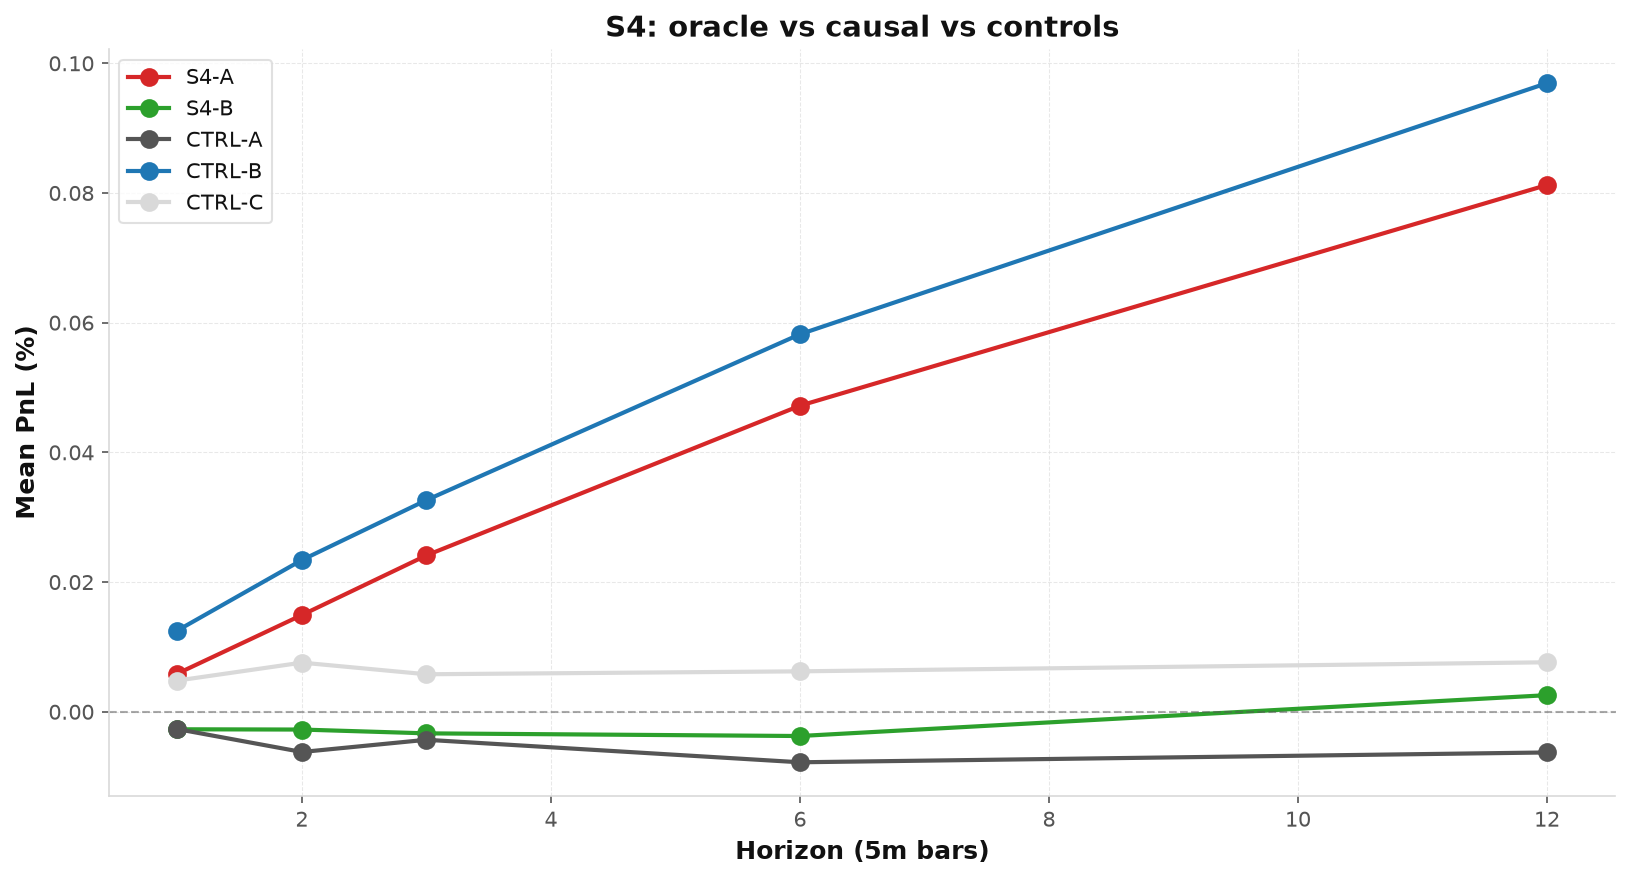

In [4]:
from oivdc_research.plotting import set_plot_style, get_palette, apply_axes_style, save_figure

set_plot_style(CONFIG.plot_theme)
pal = get_palette()

fig, ax = plt.subplots(figsize=(11, 6))
for tag, color in [("S4-A", pal["accent"]), ("S4-B", pal["long"]),
                   ("CTRL-A", pal["text_secondary"]), ("CTRL-B", pal["combined"]),
                   ("CTRL-C", pal["grid"])]:
    sub = tab[tab.src == tag]
    ax.plot(sub["h"], sub["mean_pnl"] * 100, marker="o", label=tag, color=color, linewidth=2)
ax.axhline(0, color=pal["text_secondary"], linestyle="--", linewidth=1, alpha=0.5)
ax.set_xlabel("Horizon (5m bars)")
ax.set_ylabel("Mean PnL (%)")
ax.set_title("S4: oracle vs causal vs controls")
ax.legend()
apply_axes_style(ax)
plt.tight_layout()
save_figure(fig, CONFIG.figures_dir_for("s4") / "s4_comparison.png")
plt.show()

Interpretation: S4-A is strong, S4-B ≈ 0 and bias ≈ S4-A ⇒ the entire apparent 5m edge is the result of hindsight selection. CTRL-B > CTRL-A and the wrong side is stronger than the right side ⇒ the mechanism is intraday mean reversion, amplified during gap hours (rebound), rather than a directional continuation. There is no causal 5m edge.